# BTUMQA-225K Phase 03G: Four-Seed Clean QAdp Input Ablation Shortcut Diagnostic

This notebook trains neural diagnostic baselines using only subsets of the exact clean QAdp input protocol:

- `question_embedding`
- `visual_tokens`
- `region_aux`

It answers a reviewer-facing shortcut question: can one clean input source, especially question embeddings or region auxiliary features, solve the benchmark without the full image-aware QAdp model?

This updated Phase 03G notebook preserves the original two-seed evidence for seeds `42` and `1337`, adds the missing seeds `2025` and `3407` with the same training budget, and writes a merged four-seed paper-facing package.

Interpretation rule: these are diagnostic ablations, not replacement final models.

## Dual Environment Compatibility Setup & Install Required Libraries


In [3]:
# ── DUAL ENVIRONMENT COMPATIBILITY & DEPENDENCY SETUP ────────────────────────
import os
import sys
from pathlib import Path

def resolve_project_environment(mount_point: str = "/content/drive") -> tuple[Path, Path]:
    try:
        import google.colab
        from google.colab import drive
        drive.mount(mount_point)
        project_root = Path(mount_point) / "MyDrive" / "AUGR-VQA"
        temp_dir = Path("/content")
        print("Running in Google Colab environment.")
    except ImportError:
        # Running locally (parent of notebooks directory)
        project_root = Path(os.getcwd()).parent.resolve()
        temp_dir = project_root / "temp"
        temp_dir.mkdir(parents=True, exist_ok=True)
        print("Running in Local environment.")
    return project_root, temp_dir

PROJECT_ROOT, TEMP_DIR = resolve_project_environment()
# ─────────────────────────────────────────────────────────────────────────────

import importlib
import subprocess
import sys


def ensure_package(import_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])


for import_name, pip_name in [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("sklearn", "scikit-learn"),
    ("tqdm", "tqdm"),
]:
    ensure_package(import_name, pip_name)

## Mount Google Drive and Configure Paths

In [4]:
from pathlib import Path
import os
import time

try:
    from google.colab import drive
#     drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# Updated project path to point to the new drive structure
PROJECT_DRIVE_DIR = PROJECT_ROOT

if not PROJECT_DRIVE_DIR.exists():
    PROJECT_DRIVE_DIR = Path.cwd()

# Corrected input paths: phase_3/p3a_brats_vqa_dataset/dataset_btumqa_225k
DATASET_DIR = PROJECT_DRIVE_DIR / "phase_3" / "p3a_brats_vqa_dataset" / "dataset_btumqa_225k"
if not DATASET_DIR.exists():
    local_dataset = Path.cwd() / "Dataset" / "dataset_btumqa_225k"
    if local_dataset.exists():
        DATASET_DIR = local_dataset

BTUMQA_FULL_QA_PATH = DATASET_DIR / "btumqa_225k_qa_pairs.csv"
TRAIN_CSV_PATH = DATASET_DIR / "btumqa_225k_train.csv"
VAL_CSV_PATH = DATASET_DIR / "btumqa_225k_val.csv"
TEST_CSV_PATH = DATASET_DIR / "btumqa_225k_test.csv"

# Corrected paths: phase_3/p3b_text_preprocessing/dataset_btumqa_225k
PHASE3B_DIR = PROJECT_DRIVE_DIR / "phase_3" / "p3b_text_preprocessing" / "dataset_btumqa_225k"
EMBEDDINGS_TRAIN_PATH = PHASE3B_DIR / "text_embeddings_train.pt"
EMBEDDINGS_VAL_PATH = PHASE3B_DIR / "text_embeddings_val.pt"
EMBEDDINGS_TEST_PATH = PHASE3B_DIR / "text_embeddings_test.pt"
ANSWER_VOCAB_PATH = PHASE3B_DIR / "answer_vocab.json"

# Corrected paths: phase_4/p4a_qgca_training
PHASE4_BASE_DIR = PROJECT_DRIVE_DIR / "phase_4" / "p4a_qgca_training"
VISUAL_CACHE_DIR = PHASE4_BASE_DIR / "single_stage_btumqa_225k_prugtm_45e" / "visual_cache"
VISUAL_CACHE_TENSOR_PATH = VISUAL_CACHE_DIR / "visual_slice_cache_original_tokens.pt"

# Corrected paths: phase_5/p5b_final_evaluation_ablation_calibration
PHASE5B_RESULT_DIR = (
    PROJECT_DRIVE_DIR
    / "phase_5"
    / "p5b_final_evaluation_ablation_calibration"
    / "btumqa_225k_clean_metadata_four_seeds_final_comparison"
)
if not PHASE5B_RESULT_DIR.exists():
    local_phase5b = Path.cwd() / "Res_Ck" / "5b_clean"
    if local_phase5b.exists():
        PHASE5B_RESULT_DIR = local_phase5b
SELECTED_EVIDENCE_PATH = PHASE5B_RESULT_DIR / "explanation_ready" / "selected_model_test_structured_evidence.csv"

# Corrected paths: phase_3/p3d_qa_shortcut_bias_diagnostic_baselines
PHASE03G_ORIGINAL_RESULT_FOLDER = (
    "phase_3/p3d_qa_shortcut_bias_diagnostic_baselines/"
    "btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_input_ablation"
)
PHASE03G_R02_RESULT_FOLDER = (
    "phase_3/p3d_qa_shortcut_bias_diagnostic_baselines/"
    "btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_input_ablation_r02_four_seed_extension"
)
PHASE03G_FOUR_SEED_RESULT_FOLDER = (
    "phase_3/p3d_qa_shortcut_bias_diagnostic_baselines/"
    "btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_input_ablation_four_seed_paper_package"
)
ORIGINAL_RESULT_DIR = PROJECT_DRIVE_DIR / PHASE03G_ORIGINAL_RESULT_FOLDER
EXTENSION_RESULT_DIR = PROJECT_DRIVE_DIR / PHASE03G_R02_RESULT_FOLDER
RESULT_DIR = PROJECT_DRIVE_DIR / PHASE03G_FOUR_SEED_RESULT_FOLDER
TABLE_DIR = RESULT_DIR / "tables"
FIG_DIR = RESULT_DIR / "figures"
REPORT_DIR = RESULT_DIR / "reports"
PRED_DIR = RESULT_DIR / "predictions"
MODEL_DIR = RESULT_DIR / "models"
DONE_DIR = RESULT_DIR / "done"
EXTENSION_TABLE_DIR = EXTENSION_RESULT_DIR / "tables"
EXTENSION_PRED_DIR = EXTENSION_RESULT_DIR / "predictions"
EXTENSION_MODEL_DIR = EXTENSION_RESULT_DIR / "models"
EXTENSION_REPORT_DIR = EXTENSION_RESULT_DIR / "reports"
EXTENSION_DONE_DIR = EXTENSION_RESULT_DIR / "done"

for directory in [
    TABLE_DIR,
    FIG_DIR,
    REPORT_DIR,
    PRED_DIR,
    MODEL_DIR,
    DONE_DIR,
    EXTENSION_TABLE_DIR,
    EXTENSION_PRED_DIR,
    EXTENSION_MODEL_DIR,
    EXTENSION_REPORT_DIR,
    EXTENSION_DONE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Dataset dir:", DATASET_DIR)
print("Phase 3B dir:", PHASE3B_DIR)
print("Visual cache:", VISUAL_CACHE_TENSOR_PATH)
print("Selected QAdp evidence:", SELECTED_EVIDENCE_PATH)
print("Original two-seed dir:", ORIGINAL_RESULT_DIR)
print("R02 extension dir:", EXTENSION_RESULT_DIR)
print("Four-seed paper package dir:", RESULT_DIR)

Mounted at /content/drive
Dataset dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3a_brats_vqa_dataset/dataset_btumqa_225k
Phase 3B dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3b_text_preprocessing/dataset_btumqa_225k
Visual cache: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_4_qgca_training/single_stage_btumqa_225k_prugtm_45e/visual_cache/visual_slice_cache_original_tokens.pt
Selected QAdp evidence: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/explanation_ready/selected_model_test_structured_evidence.csv
Original two-seed dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d

## Imports, Configuration, and Helper Functions

In [6]:
from __future__ import annotations

import hashlib
import json
import math
import platform
import pickle
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42

# Colab-friendly defaults. For a smoke test, set DEBUG_MAX_ROWS_PER_SPLIT = 5000.
DEBUG_MAX_ROWS_PER_SPLIT = None
RUN_SEEDS = [42, 1337, 2025, 3407]
ORIGINAL_COMPLETED_SEEDS = [42, 1337]
EXTENSION_SEEDS = [2025, 3407]
SKIP_COMPLETED_SEEDS = True
MAX_EPOCHS = 6
PATIENCE = 2
BATCH_SIZE = 512
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.2
HIDDEN_DIM = 512
NUM_WORKERS = 0
TEXT_EMBED_KEY_CANDIDATES = ["cls_last_hidden_state", "question_embedding", "pooler_output"]

ABLATION_SPECS = [
    {
        "model_key": "question_embedding_only",
        "model_label": "Question Embedding Only",
        "use_question": True,
        "use_visual": False,
        "use_region_aux": False,
        "diagnostic_question": "Can the question embedding alone solve the benchmark?",
    },
    {
        "model_key": "visual_tokens_only",
        "model_label": "Visual Tokens Only",
        "use_question": False,
        "use_visual": True,
        "use_region_aux": False,
        "diagnostic_question": "How much does the image token stream solve without question conditioning?",
    },
    {
        "model_key": "region_aux_only",
        "model_label": "Region Aux Only",
        "use_question": False,
        "use_visual": False,
        "use_region_aux": True,
        "diagnostic_question": "How much shortcut signal exists in uncertainty/region auxiliary features alone?",
    },
    {
        "model_key": "question_plus_visual",
        "model_label": "Question + Visual Tokens",
        "use_question": True,
        "use_visual": True,
        "use_region_aux": False,
        "diagnostic_question": "How strong is image-aware prediction without region auxiliary features?",
    },
    {
        "model_key": "question_plus_region_aux",
        "model_label": "Question + Region Aux",
        "use_question": True,
        "use_visual": False,
        "use_region_aux": True,
        "diagnostic_question": "Can question plus region auxiliary features solve too much without visual tokens?",
    },
    {
        "model_key": "visual_plus_region_aux",
        "model_label": "Visual Tokens + Region Aux",
        "use_question": False,
        "use_visual": True,
        "use_region_aux": True,
        "diagnostic_question": "How strong are visual-derived inputs without the question embedding?",
    },
    {
        "model_key": "simple_all_clean_inputs",
        "model_label": "Simple All Clean Inputs",
        "use_question": True,
        "use_visual": True,
        "use_region_aux": True,
        "diagnostic_question": "How strong is a simple neural baseline using the same clean input groups?",
    },
]

SLICE_COLUMNS = [
    "question_family",
    "question_style",
    "difficulty_level",
    "ambiguity_flag",
    "signal_gap_bucket",
    "region_target_primary",
    "region_target_secondary",
]


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def now_string() -> str:
    return time.strftime("%Y-%m-%d %H:%M:%S")


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def safe_torch_load(path: Path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def save_json(obj: dict, path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, indent=2, ensure_ascii=False), encoding="utf-8")
    return path


def save_table(df: pd.DataFrame, path: Path) -> pd.DataFrame:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f"Saved {len(df):,} rows -> {path}")
    return df


def append_source_columns(df: pd.DataFrame, source: str, source_path: Path) -> pd.DataFrame:
    out = df.copy()
    out["artifact_source"] = source
    out["artifact_source_path"] = str(source_path)
    return out


def compute_metrics(y_true, y_pred) -> dict:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }


def select_text_embedding_key(payload: dict) -> str:
    for key in TEXT_EMBED_KEY_CANDIDATES:
        if key in payload:
            return key
    raise KeyError(f"No supported text embedding key found. Available keys: {list(payload.keys())}")

## Load Dataset, Embeddings, Visual Cache, and Selected QAdp Evidence

In [7]:
required_paths = [
    TRAIN_CSV_PATH,
    VAL_CSV_PATH,
    TEST_CSV_PATH,
    EMBEDDINGS_TRAIN_PATH,
    EMBEDDINGS_VAL_PATH,
    EMBEDDINGS_TEST_PATH,
    ANSWER_VOCAB_PATH,
    VISUAL_CACHE_TENSOR_PATH,
]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Missing required Phase 03G inputs:\n" + "\n".join(missing_paths))

dtype_cols = {col: str for col in ["qa_id", "patient_id", "slice_id", "unique_id", "image_id"]}
df_train = pd.read_csv(TRAIN_CSV_PATH, dtype=dtype_cols).fillna("")
df_val = pd.read_csv(VAL_CSV_PATH, dtype=dtype_cols).fillna("")
df_test = pd.read_csv(TEST_CSV_PATH, dtype=dtype_cols).fillna("")

if DEBUG_MAX_ROWS_PER_SPLIT is not None:
    df_train = df_train.iloc[:DEBUG_MAX_ROWS_PER_SPLIT].copy().reset_index(drop=True)
    df_val = df_val.iloc[:DEBUG_MAX_ROWS_PER_SPLIT].copy().reset_index(drop=True)
    df_test = df_test.iloc[:DEBUG_MAX_ROWS_PER_SPLIT].copy().reset_index(drop=True)

answer_vocab = read_json(ANSWER_VOCAB_PATH)
idx_to_answer = {idx: answer for answer, idx in answer_vocab.items()}
num_answers = len(answer_vocab)


def load_embedding_payload(path: Path, df: pd.DataFrame, split_name: str) -> dict:
    payload = safe_torch_load(path, map_location="cpu")
    text_key = select_text_embedding_key(payload)
    use_rows = len(df)
    if len(payload["qa_id"]) < use_rows:
        raise ValueError(f"{split_name} embedding rows smaller than CSV rows: {len(payload['qa_id'])} < {use_rows}")
    if [str(x) for x in payload["qa_id"][:use_rows]] != df["qa_id"].astype(str).tolist():
        raise ValueError(f"{split_name} qa_id order mismatch between CSV and embeddings.")
    return {
        "qa_id": [str(x) for x in payload["qa_id"][:use_rows]],
        "question_embedding": payload[text_key][:use_rows].float().contiguous(),
        "answer_id": payload["answer_id"][:use_rows].long().contiguous(),
        "text_key": text_key,
    }


emb_train = load_embedding_payload(EMBEDDINGS_TRAIN_PATH, df_train, "train")
emb_val = load_embedding_payload(EMBEDDINGS_VAL_PATH, df_val, "val")
emb_test = load_embedding_payload(EMBEDDINGS_TEST_PATH, df_test, "test")

visual_cache_payload = safe_torch_load(VISUAL_CACHE_TENSOR_PATH, map_location="cpu")
required_cache_keys = ["unique_ids", "original_tokens", "region_aux"]
for key in required_cache_keys:
    if key not in visual_cache_payload:
        raise KeyError(f"Visual cache missing key: {key}")

cache_unique_ids = [str(x) for x in visual_cache_payload["unique_ids"]]
uid_to_cache_index = {uid: idx for idx, uid in enumerate(cache_unique_ids)}
visual_tokens_tensor = visual_cache_payload["original_tokens"].float().contiguous()
region_aux_tensor = visual_cache_payload["region_aux"].float().contiguous()

selected_evidence = None
if SELECTED_EVIDENCE_PATH.exists():
    selected_evidence = pd.read_csv(SELECTED_EVIDENCE_PATH, dtype={"qa_id": str, "unique_id": str})
    print(f"Loaded selected QAdp evidence rows: {len(selected_evidence):,}")
else:
    print("Selected QAdp evidence not found; final model comparison will use Phase 05B manually if needed.")

manifest = {
    "phase": "Phase 03G clean QAdp input ablation shortcut diagnostic",
    "created_at": now_string(),
    "train_rows": int(len(df_train)),
    "val_rows": int(len(df_val)),
    "test_rows": int(len(df_test)),
    "answer_classes": int(num_answers),
    "text_embedding_key": emb_train["text_key"],
    "question_embedding_shape": list(emb_train["question_embedding"].shape),
    "visual_tokens_shape": list(visual_tokens_tensor.shape),
    "region_aux_shape": list(region_aux_tensor.shape),
    "dataset_dir": str(DATASET_DIR),
    "phase3b_dir": str(PHASE3B_DIR),
    "visual_cache_tensor_path": str(VISUAL_CACHE_TENSOR_PATH),
    "selected_evidence_path": str(SELECTED_EVIDENCE_PATH),
    "result_dir": str(RESULT_DIR),
}
save_json(manifest, REPORT_DIR / "phase03g_clean_input_ablation_manifest.json")

print(json.dumps(manifest, indent=2)[:3000])

Loaded selected QAdp evidence rows: 33,750
{
  "phase": "Phase 03G clean QAdp input ablation shortcut diagnostic",
  "created_at": "2026-07-09 20:43:25",
  "train_rows": 157500,
  "val_rows": 33750,
  "test_rows": 33750,
  "answer_classes": 23,
  "text_embedding_key": "cls_last_hidden_state",
  "question_embedding_shape": [
    157500,
    768
  ],
  "visual_tokens_shape": [
    72025,
    6,
    512
  ],
  "region_aux_shape": [
    72025,
    6,
    4
  ],
  "dataset_dir": "/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3a_brats_vqa_dataset/dataset_btumqa_225k",
  "phase3b_dir": "/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3b_text_preprocessing/dataset_btumqa_225k",
  "visual_cache_tensor_path": "/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_4_qgca_training/single_stage_btumqa_225k_prugtm_45e/visual_c

## Dataset and Model Definitions

In [8]:
class CleanInputAblationDataset(Dataset):
    def __init__(self, df: pd.DataFrame, emb_payload: dict):
        self.df = df.reset_index(drop=True)
        self.qa_ids = self.df["qa_id"].astype(str).tolist()
        self.unique_ids = self.df["unique_id"].astype(str).tolist()
        self.question_embedding = emb_payload["question_embedding"].float().contiguous()
        self.answer_id = emb_payload["answer_id"].long().contiguous()
        self.cache_indices = []
        missing = []
        for uid in self.unique_ids:
            idx = uid_to_cache_index.get(uid)
            if idx is None:
                missing.append(uid)
            self.cache_indices.append(idx if idx is not None else -1)
        if missing:
            raise ValueError(f"Missing {len(missing)} unique_ids in visual cache. First missing: {missing[:5]}")

    def __len__(self):
        return len(self.qa_ids)

    def __getitem__(self, index: int):
        cache_index = self.cache_indices[index]
        return {
            "qa_id": self.qa_ids[index],
            "unique_id": self.unique_ids[index],
            "question_embedding": self.question_embedding[index],
            "visual_tokens": visual_tokens_tensor[cache_index],
            "region_aux": region_aux_tensor[cache_index],
            "answer_id": self.answer_id[index],
            "answer_text": self.df.loc[index, "answer"],
            "question_family": self.df.loc[index, "question_family"],
            "question_style": self.df.loc[index, "question_style"],
            "difficulty_level": self.df.loc[index, "difficulty_level"],
            "ambiguity_flag": self.df.loc[index, "ambiguity_flag"],
            "signal_gap_bucket": self.df.loc[index, "signal_gap_bucket"],
            "region_target_primary": self.df.loc[index, "region_target_primary"],
            "region_target_secondary": self.df.loc[index, "region_target_secondary"],
        }


def collate_clean_input_batch(batch: list[dict]) -> dict:
    out = {}
    tensor_keys = ["question_embedding", "visual_tokens", "region_aux", "answer_id"]
    for key in tensor_keys:
        out[key] = torch.stack([item[key] for item in batch], dim=0)
    for key in batch[0].keys():
        if key not in tensor_keys:
            out[key] = [item[key] for item in batch]
    return out


class CleanInputAblationClassifier(nn.Module):
    def __init__(self, use_question: bool, use_visual: bool, use_region_aux: bool, num_answers: int):
        super().__init__()
        self.use_question = use_question
        self.use_visual = use_visual
        self.use_region_aux = use_region_aux

        parts = []
        if use_question:
            self.question_encoder = nn.Sequential(nn.Linear(768, HIDDEN_DIM), nn.LayerNorm(HIDDEN_DIM), nn.GELU(), nn.Dropout(DROPOUT))
            parts.append(HIDDEN_DIM)
        if use_visual:
            self.visual_encoder = nn.Sequential(nn.Linear(512, HIDDEN_DIM), nn.LayerNorm(HIDDEN_DIM), nn.GELU(), nn.Dropout(DROPOUT))
            parts.append(HIDDEN_DIM)
        if use_region_aux:
            self.aux_encoder = nn.Sequential(nn.Linear(4, HIDDEN_DIM // 2), nn.LayerNorm(HIDDEN_DIM // 2), nn.GELU(), nn.Dropout(DROPOUT))
            parts.append(HIDDEN_DIM // 2)

        if not parts:
            raise ValueError("At least one input group must be enabled.")

        fusion_dim = sum(parts)
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, HIDDEN_DIM),
            nn.LayerNorm(HIDDEN_DIM),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_DIM, num_answers),
        )

    def forward(self, question_embedding, visual_tokens, region_aux):
        features = []
        if self.use_question:
            features.append(self.question_encoder(question_embedding))
        if self.use_visual:
            visual_pooled = visual_tokens.float().mean(dim=1)
            features.append(self.visual_encoder(visual_pooled))
        if self.use_region_aux:
            aux_pooled = region_aux.float().mean(dim=1)
            features.append(self.aux_encoder(aux_pooled))
        fused = torch.cat(features, dim=-1)
        return self.classifier(fused)


train_dataset = CleanInputAblationDataset(df_train, emb_train)
val_dataset = CleanInputAblationDataset(df_val, emb_val)
test_dataset = CleanInputAblationDataset(df_test, emb_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_clean_input_batch, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_clean_input_batch, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_clean_input_batch, pin_memory=torch.cuda.is_available())

sample = next(iter(train_loader))
print("Question embedding:", tuple(sample["question_embedding"].shape))
print("Visual tokens:", tuple(sample["visual_tokens"].shape))
print("Region aux:", tuple(sample["region_aux"].shape))
print("Answer:", tuple(sample["answer_id"].shape))

Question embedding: (512, 768)
Visual tokens: (512, 6, 512)
Region aux: (512, 6, 4)
Answer: (512,)


## Training and Evaluation Functions

In [9]:
def move_batch(batch: dict) -> dict:
    return {
        "question_embedding": batch["question_embedding"].to(DEVICE, non_blocking=True).float(),
        "visual_tokens": batch["visual_tokens"].to(DEVICE, non_blocking=True).float(),
        "region_aux": batch["region_aux"].to(DEVICE, non_blocking=True).float(),
        "answer_id": batch["answer_id"].to(DEVICE, non_blocking=True).long(),
    }


@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, split_name: str, collect_predictions: bool = False):
    model.eval()
    losses = []
    gold_ids = []
    pred_ids = []
    confidence_values = []
    rows = []
    criterion = nn.CrossEntropyLoss()

    for batch in loader:
        moved = move_batch(batch)
        logits = model(
            question_embedding=moved["question_embedding"],
            visual_tokens=moved["visual_tokens"],
            region_aux=moved["region_aux"],
        )
        loss = criterion(logits, moved["answer_id"])
        probs = torch.softmax(logits, dim=-1)
        confidence, pred = probs.max(dim=-1)

        losses.append(float(loss.item()) * moved["answer_id"].shape[0])
        gold_ids.extend(moved["answer_id"].detach().cpu().tolist())
        pred_ids.extend(pred.detach().cpu().tolist())
        confidence_values.extend(confidence.detach().cpu().tolist())

        if collect_predictions:
            for i in range(len(batch["qa_id"])):
                rows.append(
                    {
                        "qa_id": batch["qa_id"][i],
                        "unique_id": batch["unique_id"][i],
                        "split": split_name,
                        "gold_answer": idx_to_answer[int(gold_ids[-len(batch["qa_id"]) + i])],
                        "predicted_answer": idx_to_answer[int(pred_ids[-len(batch["qa_id"]) + i])],
                        "confidence": float(confidence_values[-len(batch["qa_id"]) + i]),
                        "question_family": batch["question_family"][i],
                        "question_style": batch["question_style"][i],
                        "difficulty_level": batch["difficulty_level"][i],
                        "ambiguity_flag": batch["ambiguity_flag"][i],
                        "signal_gap_bucket": batch["signal_gap_bucket"][i],
                        "region_target_primary": batch["region_target_primary"][i],
                        "region_target_secondary": batch["region_target_secondary"][i],
                    }
                )

    metrics = compute_metrics(gold_ids, pred_ids)
    metrics["loss"] = float(sum(losses) / max(len(gold_ids), 1))
    metrics["mean_confidence"] = float(np.mean(confidence_values)) if confidence_values else float("nan")
    return metrics, pd.DataFrame(rows)


def train_one_ablation(spec: dict, seed: int):
    seed_everything(seed)
    model = CleanInputAblationClassifier(
        use_question=spec["use_question"],
        use_visual=spec["use_visual"],
        use_region_aux=spec["use_region_aux"],
        num_answers=num_answers,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    best_state = None
    best_val_macro_f1 = -1.0
    best_epoch = 0
    stale_epochs = 0
    history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_losses = []
        progress = tqdm(train_loader, desc=f"{spec['model_label']} | seed {seed} | epoch {epoch}", leave=False)
        for batch in progress:
            moved = move_batch(batch)
            optimizer.zero_grad(set_to_none=True)
            logits = model(
                question_embedding=moved["question_embedding"],
                visual_tokens=moved["visual_tokens"],
                region_aux=moved["region_aux"],
            )
            loss = criterion(logits, moved["answer_id"])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            train_losses.append(float(loss.item()))
            progress.set_postfix(loss=float(np.mean(train_losses[-20:])))

        val_metrics, _ = evaluate_model(model, val_loader, "val", collect_predictions=False)
        epoch_row = {
            "model_key": spec["model_key"],
            "model_label": spec["model_label"],
            "seed": seed,
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        history.append(epoch_row)

        if val_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1

        print(
            f"{spec['model_label']} | seed={seed} | epoch={epoch} | "
            f"val_acc={val_metrics['accuracy']:.4f} | val_macro_f1={val_metrics['macro_f1']:.4f}"
        )

        if stale_epochs >= PATIENCE:
            print(f"Early stopping at epoch {epoch}; best epoch {best_epoch}.")
            break

    if best_state is None:
        raise RuntimeError("No best model state captured.")
    model.load_state_dict(best_state)
    val_metrics, _ = evaluate_model(model, val_loader, "val", collect_predictions=False)
    test_metrics, test_predictions = evaluate_model(model, test_loader, "test", collect_predictions=True)

    for col, value in [
        ("model_key", spec["model_key"]),
        ("model_label", spec["model_label"]),
        ("seed", seed),
        ("use_question", spec["use_question"]),
        ("use_visual", spec["use_visual"]),
        ("use_region_aux", spec["use_region_aux"]),
    ]:
        test_predictions[col] = value
    test_predictions["is_correct"] = test_predictions["gold_answer"] == test_predictions["predicted_answer"]

    model_path = EXTENSION_MODEL_DIR / f"{spec['model_key']}_seed_{seed}.pt"
    torch.save(
        {
            "model_key": spec["model_key"],
            "model_label": spec["model_label"],
            "seed": seed,
            "state_dict": model.state_dict(),
            "config": spec,
            "best_epoch": best_epoch,
            "val_metrics": val_metrics,
            "test_metrics": test_metrics,
        },
        model_path,
    )

    result_row = {
        "model_key": spec["model_key"],
        "model_label": spec["model_label"],
        "seed": seed,
        "best_epoch": best_epoch,
        "use_question": spec["use_question"],
        "use_visual": spec["use_visual"],
        "use_region_aux": spec["use_region_aux"],
        "diagnostic_question": spec["diagnostic_question"],
        **{f"val_{k}": v for k, v in val_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
        "model_path": str(model_path),
    }

    return result_row, pd.DataFrame(history), test_predictions


def load_existing_run_artifacts(spec: dict, seed: int):
    candidates = [
        {
            "source": "original_phase03g_two_seed",
            "run_level_path": ORIGINAL_RESULT_DIR / "tables" / "phase03g_clean_input_ablation_run_level_metrics.csv",
            "history_path": ORIGINAL_RESULT_DIR / "tables" / "phase03g_clean_input_ablation_training_history.csv",
            "prediction_path": ORIGINAL_RESULT_DIR / "predictions" / f"{spec['model_key']}_seed_{seed}_test_predictions.csv",
        },
        {
            "source": "r02_extension",
            "run_level_path": EXTENSION_TABLE_DIR / "phase03g_r02_extension_run_level_metrics.csv",
            "history_path": EXTENSION_TABLE_DIR / "phase03g_r02_extension_training_history.csv",
            "prediction_path": EXTENSION_PRED_DIR / f"{spec['model_key']}_seed_{seed}_test_predictions.csv",
        },
    ]

    for candidate in candidates:
        run_level_path = candidate["run_level_path"]
        prediction_path = candidate["prediction_path"]
        if not run_level_path.exists() or not prediction_path.exists():
            continue

        run_df = pd.read_csv(run_level_path)
        mask = (run_df["model_key"].astype(str) == spec["model_key"]) & (run_df["seed"].astype(int) == int(seed))
        if mask.sum() != 1:
            continue

        result_row = append_source_columns(run_df.loc[mask].copy(), candidate["source"], run_level_path).iloc[0].to_dict()
        pred_df = append_source_columns(pd.read_csv(prediction_path), candidate["source"], prediction_path)

        history_df = pd.DataFrame()
        history_path = candidate["history_path"]
        if history_path.exists():
            raw_history = pd.read_csv(history_path)
            if {"model_key", "seed"}.issubset(raw_history.columns):
                hmask = (raw_history["model_key"].astype(str) == spec["model_key"]) & (raw_history["seed"].astype(int) == int(seed))
                history_df = append_source_columns(raw_history.loc[hmask].copy(), candidate["source"], history_path)

        print(f"Loaded existing {spec['model_label']} | seed={seed} from {candidate['source']}")
        return result_row, history_df, pred_df

    return None

## Train Exact-Input Neural Ablation Baselines

In [11]:
all_result_rows = []
all_history_frames = []
all_prediction_frames = []
execution_rows = []

run_started = time.time()
print("Device:", DEVICE)
print("Ablations:", [spec["model_key"] for spec in ABLATION_SPECS])
print("Seeds:", RUN_SEEDS)
print("Skip completed seeds:", SKIP_COMPLETED_SEEDS)

for spec in ABLATION_SPECS:
    for seed in RUN_SEEDS:
        print("=" * 100)
        print(f"Resolving {spec['model_label']} | seed={seed}")
        existing = load_existing_run_artifacts(spec, seed) if SKIP_COMPLETED_SEEDS else None
        if existing is not None:
            result_row, history_df, pred_df = existing
            status = "loaded_existing"
        else:
            print(f"Training missing artifact: {spec['model_label']} | seed={seed}")
            result_row, history_df, pred_df = train_one_ablation(spec, seed)
            pred_path = EXTENSION_PRED_DIR / f"{spec['model_key']}_seed_{seed}_test_predictions.csv"
            pred_df.to_csv(pred_path, index=False)
            print("Saved extension predictions:", pred_path)
            result_row["artifact_source"] = "r02_extension_new_training"
            result_row["artifact_source_path"] = str(pred_path)
            pred_df = append_source_columns(pred_df, "r02_extension_new_training", pred_path)
            if not history_df.empty:
                history_df = append_source_columns(history_df, "r02_extension_new_training", EXTENSION_TABLE_DIR / "phase03g_r02_extension_training_history.csv")
            status = "trained"

        all_result_rows.append(result_row)
        if not history_df.empty:
            all_history_frames.append(history_df)
        all_prediction_frames.append(pred_df)
        execution_rows.append(
            {
                "model_key": spec["model_key"],
                "model_label": spec["model_label"],
                "seed": int(seed),
                "status": status,
                "artifact_source": result_row.get("artifact_source", ""),
                "artifact_source_path": result_row.get("artifact_source_path", ""),
            }
        )

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

run_minutes = round((time.time() - run_started) / 60.0, 2)
run_level_df = pd.DataFrame(all_result_rows)
expected_pairs = {(spec["model_key"], int(seed)) for spec in ABLATION_SPECS for seed in RUN_SEEDS}
observed_pairs = {(str(row["model_key"]), int(row["seed"])) for row in run_level_df.to_dict(orient="records")}
missing_pairs = sorted(expected_pairs - observed_pairs)
if missing_pairs:
    raise RuntimeError(f"Missing model/seed run rows after training/loading: {missing_pairs}")

run_counts = run_level_df.groupby("model_key")["seed"].nunique().to_dict()
bad_counts = {key: count for key, count in run_counts.items() if int(count) != len(RUN_SEEDS)}
if bad_counts:
    raise RuntimeError(f"Each ablation must have {len(RUN_SEEDS)} seeds. Bad counts: {bad_counts}")

run_level_df = save_table(run_level_df.sort_values(["model_key", "seed"]), TABLE_DIR / "phase03g_four_seed_input_ablation_run_level_metrics.csv")
execution_df = save_table(pd.DataFrame(execution_rows), TABLE_DIR / "phase03g_four_seed_input_ablation_execution_status.csv")
if all_history_frames:
    history_df = save_table(pd.concat(all_history_frames, ignore_index=True), TABLE_DIR / "phase03g_four_seed_input_ablation_training_history.csv")
else:
    history_df = pd.DataFrame()
all_predictions_df = save_table(pd.concat(all_prediction_frames, ignore_index=True), PRED_DIR / "phase03g_four_seed_input_ablation_all_test_predictions.csv")

new_training_df = run_level_df[run_level_df["artifact_source"].astype(str).str.contains("r02_extension", na=False)].copy()
if not new_training_df.empty:
    save_table(new_training_df, EXTENSION_TABLE_DIR / "phase03g_r02_extension_run_level_metrics.csv")
if all_history_frames:
    extension_history = history_df[history_df["artifact_source"].astype(str).str.contains("r02_extension", na=False)].copy()
    if not extension_history.empty:
        save_table(extension_history, EXTENSION_TABLE_DIR / "phase03g_r02_extension_training_history.csv")

print(f"Finished Phase 03G four-seed assembly in {run_minutes} minutes.")
display(run_level_df.sort_values("test_macro_f1", ascending=False))
display(execution_df)

Device: cuda
Ablations: ['question_embedding_only', 'visual_tokens_only', 'region_aux_only', 'question_plus_visual', 'question_plus_region_aux', 'visual_plus_region_aux', 'simple_all_clean_inputs']
Seeds: [42, 1337, 2025, 3407]
Skip completed seeds: True
Resolving Question Embedding Only | seed=42
Loaded existing Question Embedding Only | seed=42 from original_phase03g_two_seed
Resolving Question Embedding Only | seed=1337
Loaded existing Question Embedding Only | seed=1337 from original_phase03g_two_seed
Resolving Question Embedding Only | seed=2025
Loaded existing Question Embedding Only | seed=2025 from r02_extension
Resolving Question Embedding Only | seed=3407
Loaded existing Question Embedding Only | seed=3407 from r02_extension
Resolving Visual Tokens Only | seed=42
Loaded existing Visual Tokens Only | seed=42 from original_phase03g_two_seed
Resolving Visual Tokens Only | seed=1337
Loaded existing Visual Tokens Only | seed=1337 from original_phase03g_two_seed
Resolving Visual To

,model_key,model_label,seed,best_epoch,use_question,use_visual,use_region_aux,diagnostic_question,val_accuracy,val_macro_f1,val_weighted_f1,val_loss,val_mean_confidence,test_accuracy,test_macro_f1,test_weighted_f1,test_loss,test_mean_confidence,model_path,artifact_source,artifact_source_path
17,question_plus_region_aux,Question + Region Aux,1337,6,True,False,True,Can question plus region auxiliary features so...,0.682904,0.665490,0.666902,0.678598,0.669102,0.675822,0.663111,0.659426,0.686967,0.667720,/content/drive/MyDrive/AMIR Lab/Research Assis...,original_phase03g_two_seed,/content/drive/MyDrive/AMIR Lab/Research Assis...
19,question_plus_region_aux,Question + Region Aux,3407,6,True,False,True,Can question plus region auxiliary features so...,0.681926,0.663478,0.660451,0.668530,0.677841,0.673156,0.662695,0.652463,0.681309,0.674930,/content/drive/MyDrive/AMIR Lab/Research Assis...,r02_extension,/content/drive/MyDrive/AMIR Lab/Research Assis...
18,question_plus_region_aux,Question + Region Aux,2025,5,True,False,True,Can question plus region auxiliary features so...,0.675911,0.655812,0.659023,0.683921,0.667089,0.666400,0.652181,0.648318,0.694705,0.666505,/content/drive/MyDrive/AMIR Lab/Research Assis...,r02_extension,/content/drive/MyDrive/AMIR Lab/Research Assis...
16,question_plus_region_aux,Question + Region Aux,42,6,True,False,True,Can question plus region auxiliary features so...,0.676533,0.658253,0.659728,0.676137,0.678289,0.665304,0.649665,0.647317,0.688028,0.677513,/content/drive/MyDrive/AMIR Lab/Research Assis...,original_phase03g_two_seed,/content/drive/MyDrive/AMIR Lab/Research Assis...
24,simple_all_clean_inputs,Simple All Clean Inputs,42,6,True,True,True,How strong is a simple neural baseline using t...,0.666904,0.613995,0.653117,0.715476,0.712639,0.669126,0.620259,0.654479,0.713964,0.716801,/content/drive/MyDrive/AMIR Lab/Research Assis...,original_phase03g_two_seed,/content/drive/MyDrive/AMIR Lab/Research Assis...
25,simple_all_clean_inputs,Simple All Clean Inputs,1337,6,True,True,True,How strong is a simple neural baseline using t...,0.661956,0.613077,0.649249,0.703985,0.696487,0.665896,0.616118,0.651550,0.702518,0.702819,/content/drive/MyDrive/AMIR Lab/Research Assis...,original_phase03g_two_seed,/content/drive/MyDrive/AMIR Lab/Research Assis...
26,simple_all_clean_inputs,Simple All Clean Inputs,2025,6,True,True,True,How strong is a simple neural baseline using t...,0.666430,0.612475,0.649111,0.708908,0.707192,0.667200,0.613902,0.648122,0.718435,0.713006,/content/drive/MyDrive/AMIR Lab/Research Assis...,r02_extension,/content/drive/MyDrive/AMIR Lab/Research Assis...
27,simple_all_clean_inputs,Simple All Clean Inputs,3407,6,True,True,True,How strong is a simple neural baseline using t...,0.660148,0.600250,0.642820,0.721334,0.700092,0.664385,0.607354,0.646917,0.721724,0.705481,/content/drive/MyDrive/AMIR Lab/Research Assis...,r02_extension,/content/drive/MyDrive/AMIR Lab/Research Assis...
12,question_plus_visual,Question + Visual Tokens,42,6,True,True,False,How strong is image-aware prediction without r...,0.606430,0.497931,0.586089,0.869542,0.671439,0.610104,0.500668,0.588098,0.856562,0.676300,/content/drive/MyDrive/AMIR Lab/Research Assis...,original_phase03g_two_seed,/content/drive/MyDrive/AMIR Lab/Research Assis...
15,question_plus_visual,Question + Visual Tokens,3407,6,True,True,False,How strong is image-aware prediction without r...,0.603644,0.493670,0.581452,0.880713,0.676710,0.611230,0.497493,0.588322,0.864984,0.681965,/content/drive/MyDrive/AMIR Lab/Research Assis...,r02_extension,/content/drive/MyDrive/AMIR Lab/Research Assis...


,model_key,model_label,seed,status,artifact_source,artifact_source_path
0,question_embedding_only,Question Embedding Only,42,loaded_existing,original_phase03g_two_seed,/content/drive/MyDrive/AMIR Lab/Research Assis...
1,question_embedding_only,Question Embedding Only,1337,loaded_existing,original_phase03g_two_seed,/content/drive/MyDrive/AMIR Lab/Research Assis...
2,question_embedding_only,Question Embedding Only,2025,loaded_existing,r02_extension,/content/drive/MyDrive/AMIR Lab/Research Assis...
3,question_embedding_only,Question Embedding Only,3407,loaded_existing,r02_extension,/content/drive/MyDrive/AMIR Lab/Research Assis...
4,visual_tokens_only,Visual Tokens Only,42,loaded_existing,original_phase03g_two_seed,/content/drive/MyDrive/AMIR Lab/Research Assis...
5,visual_tokens_only,Visual Tokens Only,1337,loaded_existing,original_phase03g_two_seed,/content/drive/MyDrive/AMIR Lab/Research Assis...
6,visual_tokens_only,Visual Tokens Only,2025,loaded_existing,r02_extension,/content/drive/MyDrive/AMIR Lab/Research Assis...
7,visual_tokens_only,Visual Tokens Only,3407,loaded_existing,r02_extension,/content/drive/MyDrive/AMIR Lab/Research Assis...
8,region_aux_only,Region Aux Only,42,loaded_existing,original_phase03g_two_seed,/content/drive/MyDrive/AMIR Lab/Research Assis...
9,region_aux_only,Region Aux Only,1337,loaded_existing,original_phase03g_two_seed,/content/drive/MyDrive/AMIR Lab/Research Assis...


## Aggregate Metrics and Compare Against Selected QAdp

In [13]:
agg_rows = []
for model_key, sub in run_level_df.groupby("model_key"):
    first = sub.iloc[0]
    row = {
        "model_key": model_key,
        "model_label": first["model_label"],
        "num_runs": int(len(sub)),
        "use_question": bool(first["use_question"]),
        "use_visual": bool(first["use_visual"]),
        "use_region_aux": bool(first["use_region_aux"]),
        "diagnostic_question": first["diagnostic_question"],
    }
    for metric in ["accuracy", "macro_f1", "weighted_f1", "loss", "mean_confidence"]:
        col = f"test_{metric}"
        row[f"{col}_mean"] = float(sub[col].mean())
        row[f"{col}_std"] = float(sub[col].std(ddof=0))
    agg_rows.append(row)

ablation_agg_df = pd.DataFrame(agg_rows).sort_values(
    ["test_macro_f1_mean", "test_accuracy_mean", "test_weighted_f1_mean"],
    ascending=[False, False, False],
)

qadp_summary = None
if selected_evidence is not None:
    if "gold_answer" in selected_evidence.columns:
        gold = selected_evidence["gold_answer"].astype(str)
    elif "answer" in selected_evidence.columns:
        gold = selected_evidence["answer"].astype(str)
    else:
        gold = None
    if gold is not None and "predicted_answer" in selected_evidence.columns:
        metrics = compute_metrics(gold, selected_evidence["predicted_answer"].astype(str))
        qadp_summary = {
            "model_key": "qadp_prugtm_hybrid_qcur",
            "model_label": "QAdp-PRUGTM-Hybrid + Q-CUR",
            "num_runs": 1,
            "use_question": True,
            "use_visual": True,
            "use_region_aux": True,
            "diagnostic_question": "Selected final clean model from Phase 05B; not retrained in Phase 03G.",
            "test_accuracy_mean": metrics["accuracy"],
            "test_accuracy_std": 0.0,
            "test_macro_f1_mean": metrics["macro_f1"],
            "test_macro_f1_std": 0.0,
            "test_weighted_f1_mean": metrics["weighted_f1"],
            "test_weighted_f1_std": 0.0,
            "test_loss_mean": np.nan,
            "test_loss_std": np.nan,
            "test_mean_confidence_mean": float(pd.to_numeric(selected_evidence.get("qcur_confidence"), errors="coerce").mean()) if "qcur_confidence" in selected_evidence.columns else np.nan,
            "test_mean_confidence_std": 0.0,
        }

comparison_df = ablation_agg_df.copy()
if qadp_summary is not None:
    comparison_df = pd.concat([pd.DataFrame([qadp_summary]), comparison_df], ignore_index=True)
comparison_df = comparison_df.sort_values(
    ["test_macro_f1_mean", "test_accuracy_mean", "test_weighted_f1_mean"],
    ascending=[False, False, False],
)

ablation_agg_df = save_table(ablation_agg_df, TABLE_DIR / "phase03g_four_seed_input_ablation_aggregated_metrics.csv")
comparison_df = save_table(comparison_df, TABLE_DIR / "phase03g_four_seed_input_ablation_vs_qadp_comparison.csv")

question_only = ablation_agg_df.query("model_key == 'question_embedding_only'").iloc[0]
region_aux_only = ablation_agg_df.query("model_key == 'region_aux_only'").iloc[0]
question_region_aux = ablation_agg_df.query("model_key == 'question_plus_region_aux'").iloc[0]
simple_all = ablation_agg_df.query("model_key == 'simple_all_clean_inputs'").iloc[0]

gap_rows = []
reference_rows = [
    ("question_embedding_only", question_only),
    ("region_aux_only", region_aux_only),
    ("question_plus_region_aux", question_region_aux),
    ("simple_all_clean_inputs", simple_all),
]
if qadp_summary is not None:
    for metric in ["accuracy", "macro_f1", "weighted_f1"]:
        for ref_key, ref_row in reference_rows:
            gap_rows.append(
                {
                    "metric": metric,
                    "reference_model_key": ref_key,
                    "reference_model_label": ref_row["model_label"],
                    "qadp_value": float(qadp_summary[f"test_{metric}_mean"]),
                    "reference_value": float(ref_row[f"test_{metric}_mean"]),
                    "qadp_minus_reference": float(qadp_summary[f"test_{metric}_mean"] - ref_row[f"test_{metric}_mean"]),
                }
            )
gap_df = save_table(pd.DataFrame(gap_rows), TABLE_DIR / "phase03g_four_seed_input_ablation_qadp_gap_metrics.csv")

display(comparison_df)
display(gap_df)

Saved 7 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_input_ablation_four_seed_paper_package/tables/phase03g_four_seed_input_ablation_aggregated_metrics.csv
Saved 8 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_input_ablation_four_seed_paper_package/tables/phase03g_four_seed_input_ablation_vs_qadp_comparison.csv
Saved 12 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_input_ablation_four_seed_paper_package/tables/phase03g_four_seed_input_ablation_qadp_gap_metrics.csv


,model_key,model_label,num_runs,use_question,use_visual,use_region_aux,diagnostic_question,test_accuracy_mean,test_accuracy_std,test_macro_f1_mean,test_macro_f1_std,test_weighted_f1_mean,test_weighted_f1_std,test_loss_mean,test_loss_std,test_mean_confidence_mean,test_mean_confidence_std
0,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,1,True,True,True,Selected final clean model from Phase 05B; not...,0.929274,0.000000,0.920041,0.000000,0.931475,0.000000,NaN,NaN,0.932526,0.000000
1,question_plus_region_aux,Question + Region Aux,4,True,False,True,Can question plus region auxiliary features so...,0.670170,0.004437,0.656913,0.006057,0.651881,0.004764,0.687752,0.004758,0.671667,0.004665
2,simple_all_clean_inputs,Simple All Clean Inputs,4,True,True,True,How strong is a simple neural baseline using t...,0.666652,0.001741,0.614408,0.004668,0.650267,0.002967,0.714160,0.007264,0.709527,0.005621
3,question_plus_visual,Question + Visual Tokens,4,True,True,False,How strong is image-aware prediction without r...,0.606289,0.005547,0.495226,0.004935,0.583378,0.005164,0.855371,0.008193,0.665329,0.025376
4,question_embedding_only,Question Embedding Only,4,True,False,False,Can the question embedding alone solve the ben...,0.505504,0.002740,0.261443,0.004007,0.456180,0.002704,0.993794,0.007020,0.534019,0.002792
5,visual_plus_region_aux,Visual Tokens + Region Aux,4,False,True,True,How strong are visual-derived inputs without t...,0.158407,0.000999,0.096331,0.001693,0.131610,0.002697,2.471102,0.014816,0.191773,0.008934
6,region_aux_only,Region Aux Only,4,False,False,True,How much shortcut signal exists in uncertainty...,0.157963,0.000358,0.087169,0.001207,0.104909,0.001887,2.428251,0.005026,0.189235,0.007149
7,visual_tokens_only,Visual Tokens Only,4,False,True,False,How much does the image token stream solve wit...,0.140763,0.001612,0.078572,0.002537,0.116062,0.004237,2.634047,0.006072,0.178208,0.004490


,metric,reference_model_key,reference_model_label,qadp_value,reference_value,qadp_minus_reference
0,accuracy,question_embedding_only,Question Embedding Only,0.929274,0.505504,0.423770
1,accuracy,region_aux_only,Region Aux Only,0.929274,0.157963,0.771311
2,accuracy,question_plus_region_aux,Question + Region Aux,0.929274,0.670170,0.259104
3,accuracy,simple_all_clean_inputs,Simple All Clean Inputs,0.929274,0.666652,0.262622
4,macro_f1,question_embedding_only,Question Embedding Only,0.920041,0.261443,0.658598
5,macro_f1,region_aux_only,Region Aux Only,0.920041,0.087169,0.832872
6,macro_f1,question_plus_region_aux,Question + Region Aux,0.920041,0.656913,0.263128
7,macro_f1,simple_all_clean_inputs,Simple All Clean Inputs,0.920041,0.614408,0.305633
8,weighted_f1,question_embedding_only,Question Embedding Only,0.931475,0.456180,0.475296
9,weighted_f1,region_aux_only,Region Aux Only,0.931475,0.104909,0.826567


## Slice-Level Diagnostics for Exact-Input Ablations

In [14]:
slice_rows = []
for (model_key, seed), sub in all_predictions_df.groupby(["model_key", "seed"]):
    model_label = sub["model_label"].iloc[0]
    for col in [c for c in SLICE_COLUMNS if c in sub.columns]:
        for value, slice_sub in sub.groupby(col, dropna=False):
            if len(slice_sub) < 20:
                continue
            metrics = compute_metrics(slice_sub["gold_answer"], slice_sub["predicted_answer"])
            slice_rows.append(
                {
                    "model_key": model_key,
                    "model_label": model_label,
                    "seed": int(seed),
                    "slice_column": col,
                    "slice_value": value,
                    "rows": int(len(slice_sub)),
                    **metrics,
                }
            )
slice_run_df = pd.DataFrame(slice_rows)
slice_run_df = save_table(slice_run_df, TABLE_DIR / "phase03g_four_seed_input_ablation_slice_run_level_metrics.csv")

slice_agg_rows = []
for keys, sub in slice_run_df.groupby(["model_key", "model_label", "slice_column", "slice_value"]):
    model_key, model_label, slice_column, slice_value = keys
    row = {
        "model_key": model_key,
        "model_label": model_label,
        "slice_column": slice_column,
        "slice_value": slice_value,
        "num_runs": int(len(sub)),
        "rows_mean": float(sub["rows"].mean()),
    }
    for metric in ["accuracy", "macro_f1", "weighted_f1"]:
        row[f"{metric}_mean"] = float(sub[metric].mean())
        row[f"{metric}_std"] = float(sub[metric].std(ddof=0))
    slice_agg_rows.append(row)
slice_agg_df = save_table(
    pd.DataFrame(slice_agg_rows).sort_values(["slice_column", "slice_value", "macro_f1_mean"], ascending=[True, True, False]),
    TABLE_DIR / "phase03g_four_seed_input_ablation_slice_aggregated_metrics.csv",
)

display(slice_agg_df.head(30))

Saved 1,036 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_input_ablation_four_seed_paper_package/tables/phase03g_four_seed_input_ablation_slice_run_level_metrics.csv
Saved 252 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_input_ablation_four_seed_paper_package/tables/phase03g_four_seed_input_ablation_slice_aggregated_metrics.csv


,model_key,model_label,slice_column,slice_value,num_runs,rows_mean,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
36,question_plus_region_aux,Question + Region Aux,ambiguity_flag,no,4,22373.0,0.696699,0.008392,0.558880,0.005998,0.709108,0.005295
144,simple_all_clean_inputs,Simple All Clean Inputs,ambiguity_flag,no,4,22373.0,0.695772,0.006278,0.501432,0.014774,0.714662,0.005126
72,question_plus_visual,Question + Visual Tokens,ambiguity_flag,no,4,22373.0,0.632749,0.006643,0.438542,0.014057,0.651002,0.006449
0,question_embedding_only,Question Embedding Only,ambiguity_flag,no,4,22373.0,0.490077,0.009014,0.264449,0.021420,0.486021,0.007577
180,visual_plus_region_aux,Visual Tokens + Region Aux,ambiguity_flag,no,4,22373.0,0.171971,0.004912,0.129629,0.002784,0.153382,0.004025
108,region_aux_only,Region Aux Only,ambiguity_flag,no,4,22373.0,0.143488,0.006251,0.109349,0.004042,0.119671,0.003155
216,visual_tokens_only,Visual Tokens Only,ambiguity_flag,no,4,22373.0,0.142169,0.013570,0.102182,0.005117,0.129291,0.009834
37,question_plus_region_aux,Question + Region Aux,ambiguity_flag,yes,4,11377.0,0.618001,0.008085,0.316069,0.009629,0.640117,0.006491
145,simple_all_clean_inputs,Simple All Clean Inputs,ambiguity_flag,yes,4,11377.0,0.609387,0.014423,0.293659,0.007253,0.638055,0.009886
1,question_embedding_only,Question Embedding Only,ambiguity_flag,yes,4,11377.0,0.535840,0.021706,0.242035,0.030843,0.542852,0.015851


## Reviewer-Friendly Figures

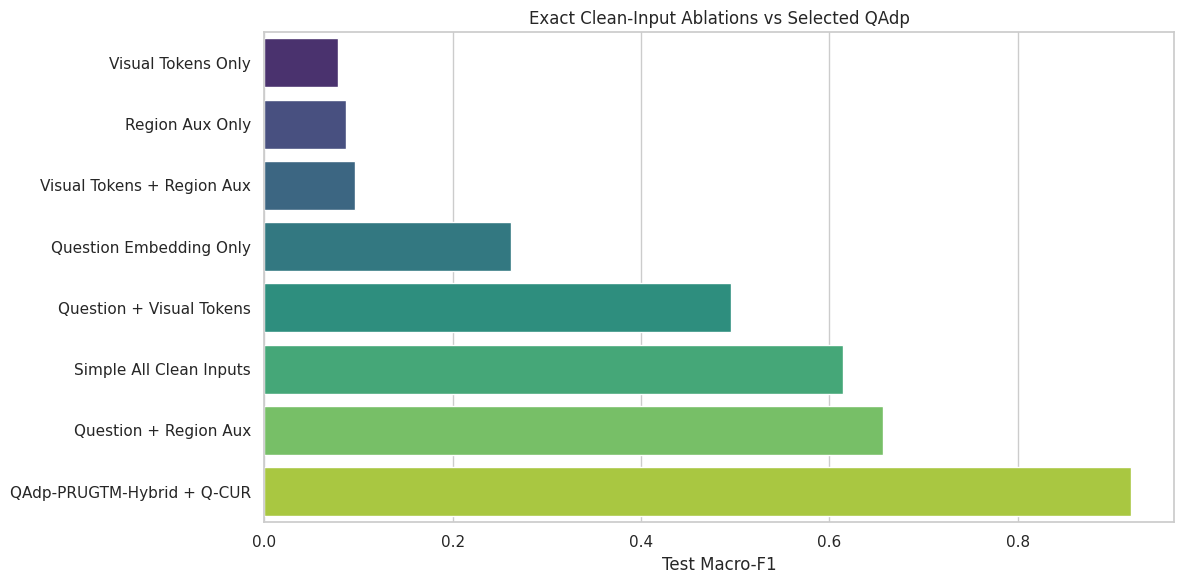

Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_input_ablation_four_seed_paper_package/figures/phase03g_four_seed_input_ablation_macro_f1_comparison.png


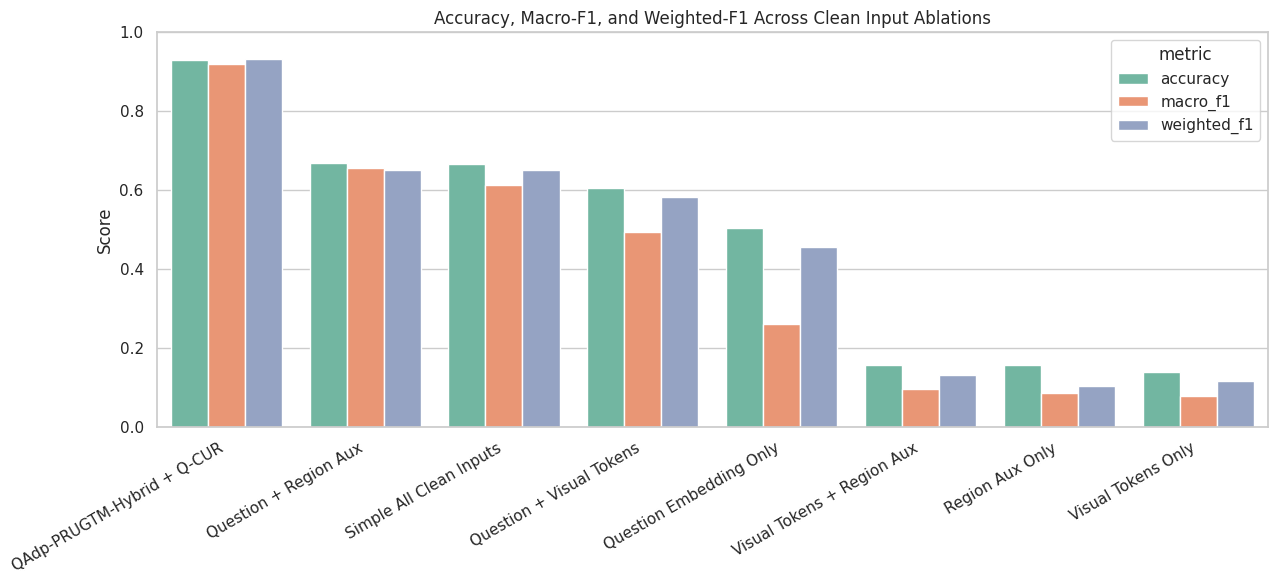

Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_input_ablation_four_seed_paper_package/figures/phase03g_four_seed_input_ablation_metric_panel.png


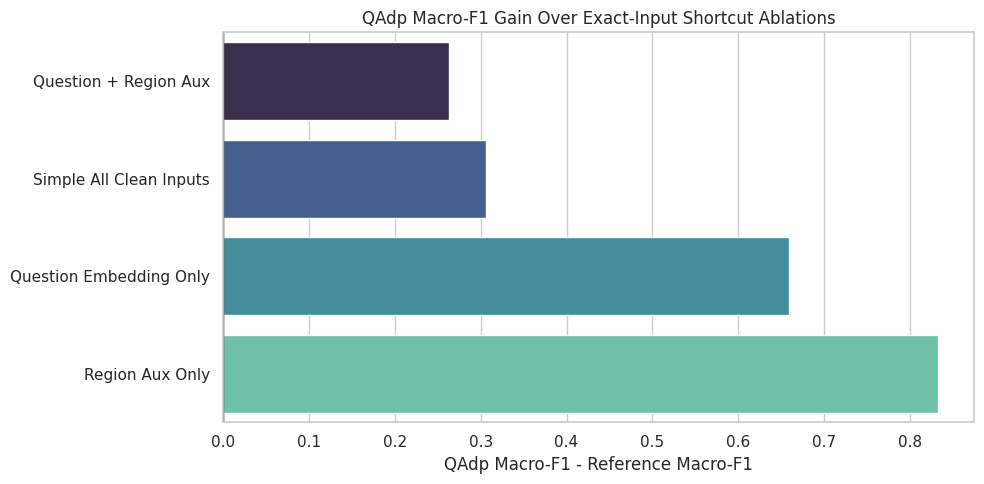

Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_input_ablation_four_seed_paper_package/figures/phase03g_four_seed_qadp_macro_f1_gain_over_input_ablations.png


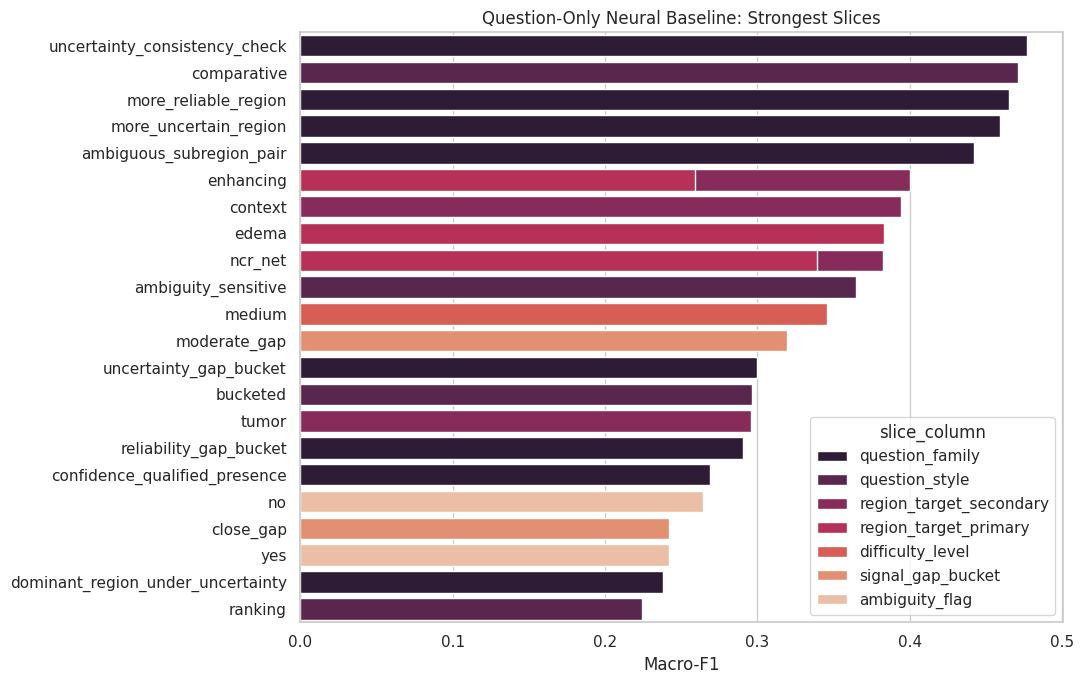

Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_input_ablation_four_seed_paper_package/figures/phase03g_four_seed_question_only_strongest_slices.png


PosixPath('/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_input_ablation_four_seed_paper_package/figures/phase03g_four_seed_question_only_strongest_slices.png')

In [16]:
def save_current_figure(name: str) -> Path:
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved figure:", path)
    return path


plot_df = comparison_df.sort_values("test_macro_f1_mean", ascending=True).copy()
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="test_macro_f1_mean", y="model_label", hue="model_label", dodge=False, legend=False, palette="viridis")
plt.xlabel("Test Macro-F1")
plt.ylabel("")
plt.title("Exact Clean-Input Ablations vs Selected QAdp")
save_current_figure("phase03g_four_seed_input_ablation_macro_f1_comparison.png")

metric_long = comparison_df.melt(
    id_vars=["model_key", "model_label"],
    value_vars=["test_accuracy_mean", "test_macro_f1_mean", "test_weighted_f1_mean"],
    var_name="metric",
    value_name="value",
)
metric_long["metric"] = metric_long["metric"].str.replace("test_", "", regex=False).str.replace("_mean", "", regex=False)
plt.figure(figsize=(13, 6))
sns.barplot(data=metric_long, x="model_label", y="value", hue="metric", palette="Set2")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.0)
plt.title("Accuracy, Macro-F1, and Weighted-F1 Across Clean Input Ablations")
plt.xlabel("")
plt.ylabel("Score")
save_current_figure("phase03g_four_seed_input_ablation_metric_panel.png")

if not gap_df.empty:
    plt.figure(figsize=(10, 5))
    gap_plot = gap_df[gap_df["metric"] == "macro_f1"].sort_values("qadp_minus_reference")
    sns.barplot(data=gap_plot, x="qadp_minus_reference", y="reference_model_label", hue="reference_model_label", dodge=False, legend=False, palette="mako")
    plt.axvline(0, color="black", linewidth=1)
    plt.title("QAdp Macro-F1 Gain Over Exact-Input Shortcut Ablations")
    plt.xlabel("QAdp Macro-F1 - Reference Macro-F1")
    plt.ylabel("")
    save_current_figure("phase03g_four_seed_qadp_macro_f1_gain_over_input_ablations.png")

question_only_slices = slice_agg_df.query("model_key == 'question_embedding_only'").sort_values("macro_f1_mean", ascending=False).head(25)
plt.figure(figsize=(11, 7))
sns.barplot(data=question_only_slices, x="macro_f1_mean", y="slice_value", hue="slice_column", dodge=False, palette="rocket")
plt.title("Question-Only Neural Baseline: Strongest Slices")
plt.xlabel("Macro-F1")
plt.ylabel("")
save_current_figure("phase03g_four_seed_question_only_strongest_slices.png")

## Final Report and Done Marker

In [17]:
report = {
    "finished_at": now_string(),
    "phase": "Phase 03G four-seed clean QAdp input ablation shortcut diagnostic",
    "purpose": "Reviewer-facing four-seed exact-input neural shortcut/ablation audit for question_embedding, visual_tokens, and region_aux.",
    "dataset_dir": str(DATASET_DIR),
    "phase3b_dir": str(PHASE3B_DIR),
    "visual_cache_tensor_path": str(VISUAL_CACHE_TENSOR_PATH),
    "selected_qadp_evidence_path": str(SELECTED_EVIDENCE_PATH),
    "original_two_seed_result_dir": str(ORIGINAL_RESULT_DIR),
    "extension_result_dir": str(EXTENSION_RESULT_DIR),
    "result_dir": str(RESULT_DIR),
    "run_seeds": RUN_SEEDS,
    "original_completed_seeds": ORIGINAL_COMPLETED_SEEDS,
    "extension_seeds": EXTENSION_SEEDS,
    "skip_completed_seeds": SKIP_COMPLETED_SEEDS,
    "training_config": {
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "debug_max_rows_per_split": DEBUG_MAX_ROWS_PER_SPLIT,
    },
    "execution_status": execution_df.to_dict(orient="records"),
    "ablation_ranking": comparison_df.to_dict(orient="records"),
    "qadp_gap_metrics": gap_df.to_dict(orient="records") if not gap_df.empty else [],
    "paper_safe_interpretation": [
        "Phase 03G combines preserved original seeds 42/1337 with extension seeds 2025/3407 for four-seed exact-input ablation reporting.",
        "Phase 03G uses exact clean input groups to test shortcut risk under neural baselines.",
        "Question-embedding-only performance estimates how much can be solved from question text embeddings alone.",
        "Region-aux-only and question-plus-region-aux performance estimate whether uncertainty/region auxiliary features carry excessive answer signal without visual tokens.",
        "The selected QAdp-PRUGTM-Hybrid result is imported from Phase 05B and is not retrained in this notebook.",
        "Do not claim bias-free behavior; report exact-input ablation gaps as evidence for or against multimodal value.",
    ],
}
save_json(report, REPORT_DIR / "phase03g_four_seed_input_ablation_final_report.json")
save_json(
    {
        "status": "complete",
        "finished_at": now_string(),
        "report": str(REPORT_DIR / "phase03g_four_seed_input_ablation_final_report.json"),
        "run_seeds": RUN_SEEDS,
    },
    DONE_DIR / "phase03g_four_seed_input_ablation_complete.json",
)

print(json.dumps(report, indent=2)[:4000])

{
  "finished_at": "2026-07-09 21:43:21",
  "phase": "Phase 03G four-seed clean QAdp input ablation shortcut diagnostic",
  "purpose": "Reviewer-facing four-seed exact-input neural shortcut/ablation audit for question_embedding, visual_tokens, and region_aux.",
  "dataset_dir": "/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3a_brats_vqa_dataset/dataset_btumqa_225k",
  "phase3b_dir": "/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3b_text_preprocessing/dataset_btumqa_225k",
  "visual_cache_tensor_path": "/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_4_qgca_training/single_stage_btumqa_225k_prugtm_45e/visual_cache/visual_slice_cache_original_tokens.pt",
  "selected_qadp_evidence_path": "/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_eval

## Quick Inspect Phase 03G Artifacts

In [18]:
print("Tables:")
for path in sorted(TABLE_DIR.glob("*.csv")):
    print(" -", path.name)
print("\nPredictions:")
for path in sorted(PRED_DIR.glob("*.csv")):
    print(" -", path.name)
print("\nFigures:")
for path in sorted(FIG_DIR.glob("*.png")):
    print(" -", path.name)
print("\nReports:")
for path in sorted(REPORT_DIR.glob("*.json")):
    print(" -", path.name)

Tables:
 - phase03g_four_seed_input_ablation_aggregated_metrics.csv
 - phase03g_four_seed_input_ablation_execution_status.csv
 - phase03g_four_seed_input_ablation_qadp_gap_metrics.csv
 - phase03g_four_seed_input_ablation_run_level_metrics.csv
 - phase03g_four_seed_input_ablation_slice_aggregated_metrics.csv
 - phase03g_four_seed_input_ablation_slice_run_level_metrics.csv
 - phase03g_four_seed_input_ablation_training_history.csv
 - phase03g_four_seed_input_ablation_vs_qadp_comparison.csv

Predictions:
 - phase03g_four_seed_input_ablation_all_test_predictions.csv

Figures:
 - phase03g_four_seed_input_ablation_macro_f1_comparison.png
 - phase03g_four_seed_input_ablation_metric_panel.png
 - phase03g_four_seed_qadp_macro_f1_gain_over_input_ablations.png
 - phase03g_four_seed_question_only_strongest_slices.png

Reports:
 - phase03g_clean_input_ablation_manifest.json
 - phase03g_four_seed_input_ablation_final_report.json
